# ExodusPoint - Research Test - Saam Nazempour

## README: 
This notebook is quite long as i have decided to leave in a lot of the debugging and working things out i did over the course of the project. 

So if you want to go straight to the results: At the end of each main section (Strategy 1, Strategy 2 etc.) there is a class which contains the models inner workings. The cell directly after the class plots informative graphs and performance metrics of the model (eg: sharpe ratio, train/test scores etc.)

If you have any questions about this project please don't hesistate to contact me: saamnazem@gmail.com

Thank you for looking at this project! I spent a fair bit more than 5 hours on this, but I learn't a lot in the process and it was genuinely quite enjoyable!


## Abstract
In this notebook, I developed and evaluated two types of trading strategies: a mean-reversion pairs trading model and an event-driven trading model. For each strategy, I implemented both a rule-based approach and a machine learning approach using random forest classifiers. The models were tested on the ten year long historical data to assess their performance. Due to time constraints, I was unable to fully optimise the classification models, leaving potential for further improvements in their accuracy and effectiveness. Despite this, the models provide a foundational framework for exploring rule-based and machine learning approaches in quantitative trading.

## Introduction

This being my first time tasked with thinking about and developing trading strategies, I spent a large portion of time before starting to write code on researching to decide on which strategies I would want to implement. After some time, I narrowed down the options to some sort of mean reversion strategy and a purely events driven strategy. I really enjoyed coding up these strategies and playing with the parameters and features to see how the buy/sell signals would change, and I feel I learnt a lot, even though the models here were very basic. There were so many more ideas I would've liked to try and things I would've wanted to optimise and develop, but due to my academic commitment this year, I couldn't spend much more time on this research.

The mean reversion model (Strategies 1 and 2) works as follows: 
- First check the correlation of the stock pair and the stationarity; if they pass a minimum threshold, then it is eligible for the strategy
- Compute the cumulative returns of the stocks (mirrors the price over time, as we are not given the prices)
- Compute the spread between these cumulative returns.
- Compute the expected mean of the spread (longer term rolling mean of the spread)
- Compare the short term fluctuations (short rolling window) of the spread to the expected mean (long rolling window)
- If this spread rises above a given (eg. Z = ±2) or learned threshold, execute a buy/sell.
- Hold the position until the short term price fluctation reaches an exit threshold, that is given or learned.


The events driven model (strategies 3 and 4) works as follows:
- For the chosen stock, extract the cumulative returns centered around the event dates across the 10 year period.
- Compute the expected (mean) of these reactions to the events.
- Fit the mean with a second order linear regression
- If the expected reaction to events shows strong polynomial behaviour (check with the RMSE of the fit)
- If the RMSE of the fit is below some given threshold, initialise the strategy
- If the coefficient of the polynomial is positive execute a sell/buy/sell based on the edges and the minima of the polynomial
- If the coefficient of the polynomial is negative execute a buy/sell/buy, based on the edges and the maxima of the polynomial

# Table of Contents

[Preliminary Work](#pre-liminary-work-and-ideas)

[Strategy 1: Mean Reversion Pairs Trading Model (Rule_based)](#strategy-1-mean-reversion-pairs-trading-rule-based)

[Strategy 2: Mean Reversion Pairs Trading Model (ML Approach)](#strategy-3-events-driven-trading-rule-based)

[Strategy 2b: An attempt to optimise input parameters](#feature-engineering---improve-the-performance)

[Strategy 3: Events Driven Trading (Rule-Based)](#strategy-3-events-driven-trading-rule-based)

[Strategy 4: Events Driven Trading (ML approach)](#strategy-4-events-driven-trading-model-ml-approach)

[Conclusion and Future Research Directions](#conclusion-and-future-research-directions)

# Pre-liminary Work and Ideas

Importing necessary packages

In [4]:
# Importing the libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.tsa.stattools as ts
from statsmodels.tsa.stattools import adfuller
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error

Global Functions for idea testing

In [5]:
# Global functions for testing and analysis

def cumulative_returns(df):
    return (1 + df).cumprod() - 1

def highest_correlation(stock_no):
    return cumulative_df.corr().iloc[stock_no,:].sort_values(ascending=False)

def diff_df(df, stock_no_initial, stock_no_final):
    return df[stock_no_final] - df[stock_no_initial]


def spread_df(df, stock_no_initial, stock_no_final):
    return df[stock_no_initial] - df[stock_no_final]

def z_score(df):
    return (df - df.mean())/df.std()

def gaussian(x, mu, sig, a):
    return a * np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))

Loading and visualising the dataset

In [6]:
# Loading the stock returns data and setting the index to be a datetime index

df_stock_returns = pd.read_csv('stock_returns.csv', index_col=0)
df_stock_returns.index = pd.to_datetime(df_stock_returns.index)

df_events = pd.read_csv('events.csv', index_col=0)
df_events.index = pd.to_datetime(df_events.index)

In [7]:
# Checking for null values

print(f'The total number of null values (stock) = {df_stock_returns.isnull().sum().sum()}')
print(f'The total number of null values (events) = {df_events.isnull().sum().sum()}')

The total number of null values (stock) = 0
The total number of null values (events) = 0


In [8]:
# Displaying the first 5 rows of the stock returns data

df_stock_returns.head()

,stock_0,stock_1,stock_2,stock_3,stock_4,stock_5,stock_6,stock_7,stock_8,stock_9,...,stock_90,stock_91,stock_92,stock_93,stock_94,stock_95,stock_96,stock_97,stock_98,stock_99
2008-01-01,-0.060491,-0.080500,-0.050660,0.081462,0.098972,-0.053602,-0.072472,-0.037347,0.060453,-0.016243,...,0.061247,-0.006513,-0.024229,0.049695,0.108936,-0.024647,-0.069053,-0.080621,0.122550,0.137066
2008-01-02,0.049349,0.081020,0.069192,-0.072143,-0.071797,0.009172,0.077189,0.013204,-0.034571,0.067204,...,0.102941,0.062913,0.050651,0.051257,-0.043803,0.043607,0.063883,0.018711,-0.048830,-0.031252
2008-01-03,0.059473,0.032091,0.024066,-0.039715,-0.052799,0.052004,0.015510,0.040422,-0.060424,0.050653,...,0.050570,0.060061,0.023991,0.077297,-0.043031,0.043916,0.044098,0.038019,0.012805,-0.018240
2008-01-04,-0.044314,-0.130776,-0.093305,-0.084950,-0.127698,-0.113898,-0.093985,-0.081634,-0.112844,-0.071077,...,-0.058796,-0.081851,-0.089890,-0.067309,-0.084365,-0.064657,-0.109007,-0.100333,-0.128903,-0.109756
2008-01-07,-0.105824,-0.053267,-0.068796,0.013980,0.027369,-0.070220,-0.058303,-0.070570,0.011305,-0.126058,...,-0.093418,-0.128418,-0.073323,-0.105747,0.017285,-0.111904,-0.084216,-0.053886,-0.005440,0.070030


In [9]:
# Displaying the first 5 rows of the events data

df_events.head()

,stock_0,stock_1,stock_2,stock_3,stock_4,stock_5,stock_6,stock_7,stock_8,stock_9,...,stock_90,stock_91,stock_92,stock_93,stock_94,stock_95,stock_96,stock_97,stock_98,stock_99
2008-01-01,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
2008-01-02,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2008-01-03,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2008-01-04,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2008-01-07,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Statistics of the Data

In [10]:
# Describe the stock returns data

df_stock_returns.describe().loc[['mean','std', 'max', 'min']]

,stock_0,stock_1,stock_2,stock_3,stock_4,stock_5,stock_6,stock_7,stock_8,stock_9,...,stock_90,stock_91,stock_92,stock_93,stock_94,stock_95,stock_96,stock_97,stock_98,stock_99
mean,0.000252,-0.000762,-0.000959,0.000844,0.001443,-0.001395,-0.001603,-0.001193,0.001024,0.000402,...,0.000127,-0.000088,-0.000687,0.000485,0.000895,0.001145,-0.001162,0.000193,0.002292,0.002603
std,0.061771,0.062279,0.062386,0.064229,0.064722,0.062511,0.062905,0.061648,0.064042,0.061879,...,0.061776,0.061757,0.062278,0.061301,0.063568,0.061909,0.061629,0.061524,0.063652,0.063829
max,0.229916,0.204153,0.217383,0.222713,0.233509,0.215000,0.202707,0.208654,0.223447,0.208604,...,0.209139,0.217685,0.220883,0.200005,0.243320,0.219000,0.223233,0.224756,0.240095,0.229653
min,-0.254952,-0.193027,-0.237213,-0.198531,-0.224382,-0.205776,-0.215313,-0.207084,-0.217803,-0.202628,...,-0.197306,-0.182616,-0.213802,-0.203070,-0.203986,-0.220657,-0.187446,-0.246171,-0.218610,-0.229977


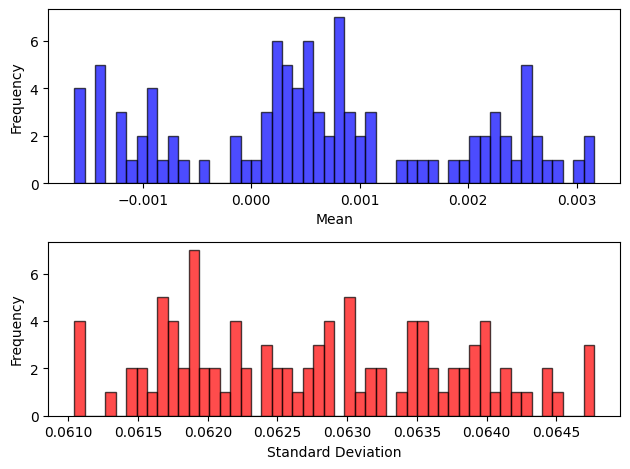

In [11]:
# Visulasing the distribution of the mean and standard deviation of the stock returns

means = df_stock_returns.describe().loc['mean']
stds = df_stock_returns.describe().loc['std']


fig, axes = plt.subplots(nrows=2, ncols=1)

axes[0].hist(means, bins = 50, alpha = 0.7, color = 'blue', edgecolor = 'black')
axes[0].set_xlabel('Mean')
axes[0].set_ylabel('Frequency')


axes[1].hist(stds, bins = 50, alpha = 0.7, color = 'red', edgecolor = 'black')
axes[1].set_xlabel('Standard Deviation')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


We expect the means of the stocks to be normally distributed as expected from the central limit theorem. We can see a normal distbution envelope with high ends on each tail. This may come in handy later for the strategy.

In [12]:
# Stocks with maximum cumulative returns over the 10 year period

top_10_creturns = cumulative_returns(df_stock_returns).max().sort_values(ascending=False).head(10).index

I have plotted here the top 10 performers of stocks by way of maximum cumulative returns reached at some point within the 10 years.

Text(0, 0.5, 'Cumulative Returns (%)')

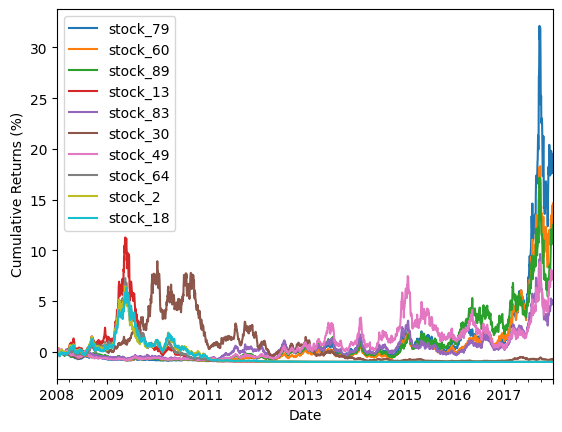

In [13]:
# Plotting the cumulative returns of the top 10 stocks

cumulative_returns(df_stock_returns[top_10_creturns]).plot()
plt.xlabel('Date')
plt.ylabel('Cumulative Returns (%)')    

## Setting up the Idea of Mean Reversion 

Idea:
- First I will calculate the correlation between the cumulative returns of the stocks
- Only stock pairs with p > x, where x is to be set, will be selected for this strategy
- Of the selected pairs, those with a stationary (mean) spread and ratio will be further selected
- Using a MA model we can monitor the relationship between the short term spread and the mean
- If current prices fall above or below the confidence interval we wil execute the trade
- We can look at the performance of the signals on the final spread

### Setting up and testing Ideas

In [14]:
# DataFrame of the cumulative returns

cumulative_df = cumulative_returns(df_stock_returns)

In [15]:
# Highest correlation with the first stock

corr_0 = highest_correlation(0)

Plotting the cumulative returns for the 4 most correlated stocks to stock_0

<Axes: >

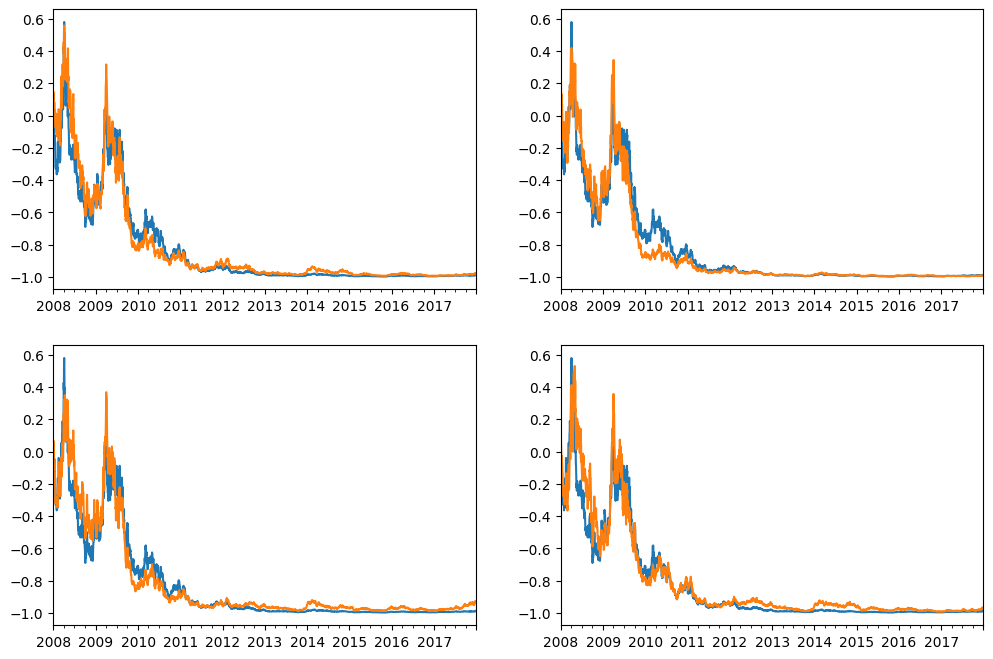

In [16]:
# Visualisation - Plotting the cumulative returns of the first stock and the top 4 stocks with the highest correlation

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 10))

cumulative_df['stock_0'].plot(ax = axes[0,0], figsize=(12, 8))
cumulative_df[corr_0.index[1]].plot(ax = axes[0,0], figsize=(12, 8))

cumulative_df['stock_0'].plot(ax = axes[0,1], figsize=(12, 8))
cumulative_df[corr_0.index[2]].plot(ax = axes[0,1], figsize=(12, 8))

cumulative_df['stock_0'].plot(ax = axes[1,0], figsize=(12, 8))
cumulative_df[corr_0.index[3]].plot(ax = axes[1,0], figsize=(12, 8))

cumulative_df['stock_0'].plot(ax = axes[1,1], figsize=(12, 8))
cumulative_df[corr_0.index[4]].plot(ax = axes[1,1], figsize=(12, 8))

Plotting the spreads of these 4 pairs, overlayed with their means

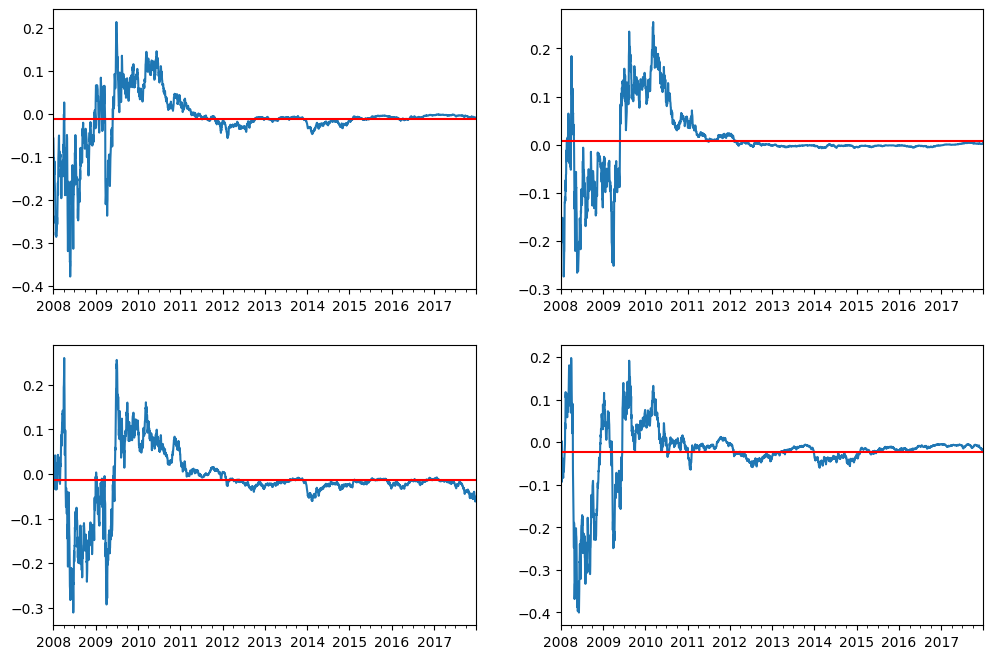

In [17]:
# Plotting the spreads for the top 4 stocks with the highest correlation with stock_0


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 10))

(spread_df(cumulative_df, 'stock_0', corr_0.index[1])).plot(ax = axes[0,0], figsize=(12, 8))
axes[0,0].axhline(spread_df(cumulative_df, 'stock_0', corr_0.index[1]).mean(), color = 'red')

(spread_df(cumulative_df, 'stock_0', corr_0.index[2])).plot(ax = axes[0,1], figsize=(12, 8))
axes[0,1].axhline(spread_df(cumulative_df, 'stock_0', corr_0.index[2]).mean(), color = 'red')

(spread_df(cumulative_df, 'stock_0', corr_0.index[3])).plot(ax = axes[1,0], figsize=(12, 8))
axes[1,0].axhline(spread_df(cumulative_df, 'stock_0', corr_0.index[3]).mean(), color = 'red')

(spread_df(cumulative_df, 'stock_0', corr_0.index[4])).plot(ax = axes[1,1], figsize=(12, 8))
axes[1,1].axhline(spread_df(cumulative_df, 'stock_0', corr_0.index[4]).mean(), color = 'red')


Checking for stationarity of these spreads and ratios

In [18]:
spread_df(cumulative_df, 'stock_0', corr_0.index[1])

2008-01-01   -0.057594
2008-01-02   -0.082707
2008-01-03   -0.100784
2008-01-04   -0.118781
2008-01-07   -0.102649
                ...   
2017-12-25   -0.010301
2017-12-26   -0.009072
2017-12-27   -0.010558
2017-12-28   -0.011009
2017-12-29   -0.009578
Length: 2609, dtype: float64

In [19]:
# Test 1: cointergration test
# Detemines if the spread between the stocks is stationary - easier to predict

result = ts.coint(cumulative_df[corr_0.index[0]], cumulative_df[corr_0.index[1]])

cointegration_t_stat = result[0]
p_val = result[1]

print(f'P value (Ideally < 0.05) :{p_val}')

if p_val < 0.05:
    print(f'The spread is stationary between {corr_0.index[0]} and {corr_0.index[1]}')


P value (Ideally < 0.05) :0.0034915469530428156
The spread is stationary between stock_0 and stock_16


In [20]:
# Test 2: ADF test

spread_ADF = adfuller(spread_df(cumulative_df, 'stock_0', corr_0.index[1]))

ratio_ADF = adfuller(cumulative_df[corr_0.index[0]]/cumulative_df[corr_0.index[1]])


print(f'The p-value for the ADF test is {spread_ADF[1]} \nThe p-value for the ratio ADF test is {ratio_ADF[1]}')

if spread_ADF[1] < 0.05:
    print(f'The spread is stationary between {corr_0.index[0]} and {corr_0.index[1]}')

The p-value for the ADF test is 0.0002604500254368111 
The p-value for the ratio ADF test is 1.6498666946188384e-20
The spread is stationary between stock_0 and stock_16


# Strategy 1: Mean Reversion Pairs Trading (Rule-Based)

- Using Z-score (x-mean/std)
- Calculate the z score spread of the cumlative return spread 
- Generate buy/sell signals for alpha based on the MA fluctuations in the long and short term.
- We are doing mean reversion where the mean is a dynamic mean that depends on the longer term moving average. If the short term MA fluctuates significantly away from the long term MA we will predict a reversion to the longer term mean, and as a result place this as a signal.

### Setting up the idea

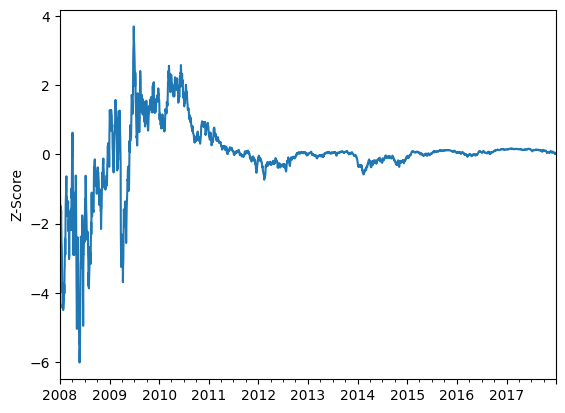

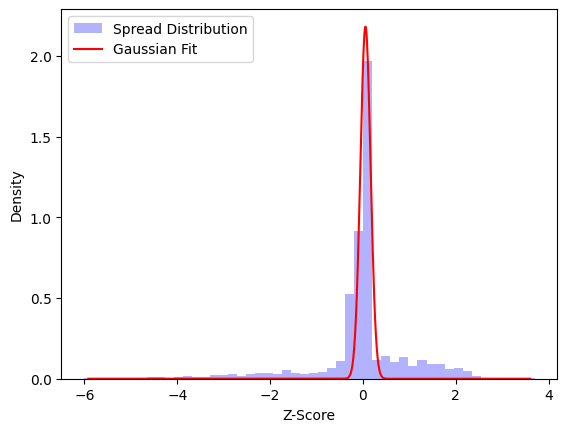

In [21]:
# Z-score of cumulative spread between stock_0 and the stocks with highqest correlation/stationarity (eg stock_16)

hist_values, bin_edges = np.histogram(z_score(spread_df(cumulative_df, corr_0.index[0], corr_0.index[1])), bins=50, density=True)

bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])

popt, _ = curve_fit(gaussian, bin_centers, hist_values, p0=[0, 1, max(hist_values)])

z_score(spread_df(cumulative_df, corr_0.index[0], corr_0.index[1])).plot()
plt.ylabel('Z-Score')
plt.show()


plt.hist(z_score(spread_df(cumulative_df, corr_0.index[0], corr_0.index[1])), bins = 50, density = True, alpha = 0.3, color = 'blue', label = 'Spread Distribution')
plt.plot(np.linspace(bin_centers.min(),bin_centers.max(),1000), gaussian(np.linspace(bin_centers.min(),bin_centers.max(),1000), *popt), color = 'red', label = 'Gaussian Fit')
plt.ylabel('Density')
plt.xlabel('Z-Score')
plt.legend()

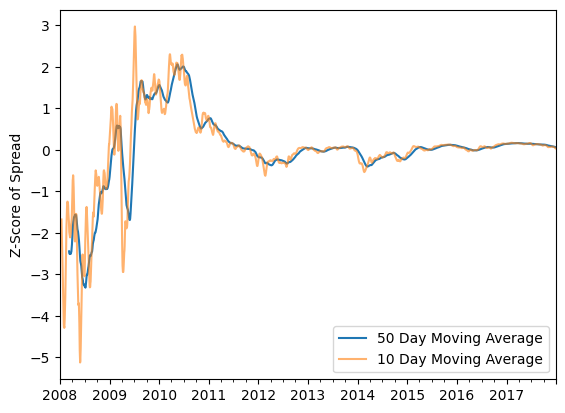

In [22]:
# Moving average of the z-score of the spread between stock_0 and stock_16

# Plots both the 10 and 50 day moving averages

z_score(spread_df(cumulative_df, corr_0.index[0], corr_0.index[1])).rolling(window=50).mean().plot(label = '50 Day Moving Average')
z_score(spread_df(cumulative_df, corr_0.index[0], corr_0.index[1])).rolling(window=10).mean().plot(label = '10 Day Moving Average', alpha = 0.6)
plt.ylabel('Z-Score of Spread')
plt.legend(loc = 'lower right')

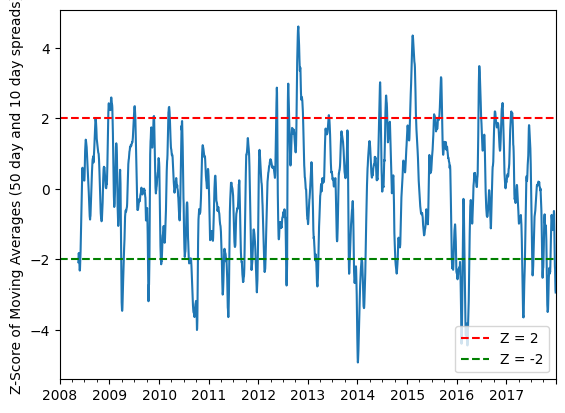

In [23]:
# Plots the Z-Score of the spread between the 10 and 50 day moving averages (stock_0 and stock_16)
# Which itself is the spread between the cumulative returns of stock_0 and stock_16
# We will be looking for Z-Scores greater than 2 or less than -2 to indicate a potential trading opportunity

diff_MA = spread_df(cumulative_df, corr_0.index[0], corr_0.index[1]).rolling(window=10).mean() - spread_df(cumulative_df, corr_0.index[0], corr_0.index[1]).rolling(window=50).mean()
std_50_MA = diff_MA.rolling(window=50, center = False).std()

Z_score_MA = diff_MA/std_50_MA

Z_score_MA.plot()
plt.axhline(2, color = 'red', label = 'Z = 2', linestyle = '--')
plt.axhline(-2, color = 'green', label = 'Z = -2', linestyle = '--')
plt.ylabel('Z-Score of Moving Averages (50 day and 10 day spreads)')
plt.legend(loc = 'lower right')


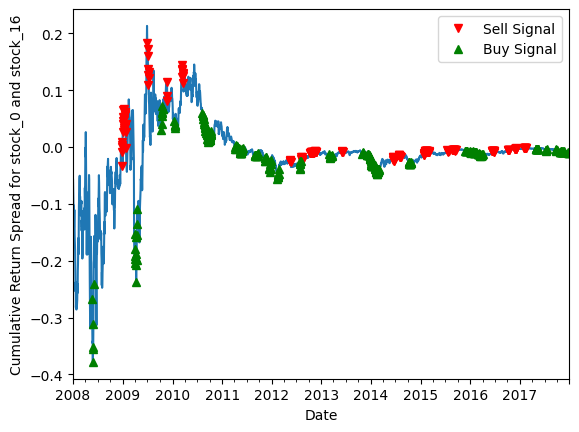

In [24]:
# Cumulative spread between stock_0 and stock_16
# Buy signal when Z_score_MA < -2
# Sell signal when Z_score_MA > 2

spread_df(cumulative_df, corr_0.index[0], corr_0.index[1]).plot()
spread_df(cumulative_df, corr_0.index[0], corr_0.index[1])[Z_score_MA > 2].plot(color = 'red', label = 'Sell Signal', linestyle = 'None', marker = 'v')
spread_df(cumulative_df, corr_0.index[0], corr_0.index[1])[Z_score_MA < -2].plot(color = 'green', label = 'Buy Signal', linestyle = 'None', marker = '^')
plt.ylabel(f'Cumulative Return Spread for {corr_0.index[0]} and {corr_0.index[1]}')
plt.xlabel('Date')
plt.legend()

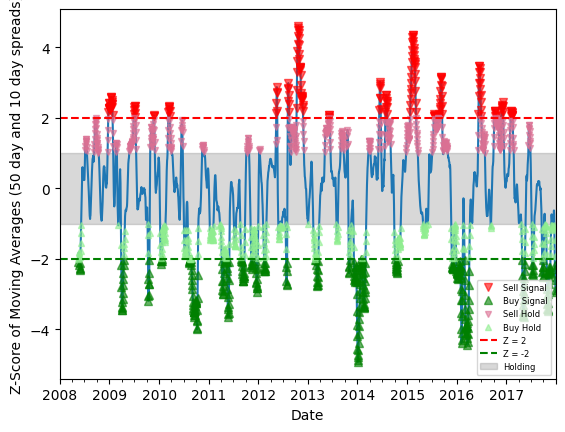

In [25]:
# Rule-based trading strategy for this model
# This strategy will be based on the Z-Score of the spread between the 10 and 50 day moving averages of the cumulative spread of stock_0 and stock_16.
# A Z-Score greater than 2 will be a sell signal
# A Z-Score less than -2 will be a buy signal
# A Z-Score between -1 and 1 will be a hold signal  

Z_score_MA.plot()
Z_score_MA[Z_score_MA > 2].plot(color = 'red', label = 'Sell Signal', linestyle = 'None', marker = 'v', alpha = 0.6)
Z_score_MA[Z_score_MA < -2].plot(color = 'green', label = 'Buy Signal', linestyle = 'None', marker = '^', alpha = 0.6)
Z_score_MA[Z_score_MA > 1][Z_score_MA < 2].plot(color = 'palevioletred', label = 'Sell Hold', linestyle = 'None', marker = 'v', markersize = 4, alpha = 0.6)
Z_score_MA[Z_score_MA < -1][Z_score_MA > -2].plot(color = 'lightgreen', label = 'Buy Hold', linestyle = 'None', marker = '^', markersize = 4, alpha = 0.6)
plt.axhline(2, color = 'red', label = 'Z = 2', linestyle = '--')
plt.axhline(-2, color = 'green', label = 'Z = -2', linestyle = '--')
plt.axhspan(-1,1, label = 'Holding', color = 'grey', alpha = 0.3)
plt.ylabel('Z-Score of Moving Averages (50 day and 10 day spreads)')
plt.xlabel('Date')
plt.legend(loc = 'lower right', fontsize = 6)

### Extracting the Sharpe Ratio - Excess gains normalised by the volatility


In [26]:
# Calculating the daily returns of the strategy
# Then appends the (posiiton * daily returns) of the strategy to the daily returns list (+1 for buy, -1 for sell, 0 for hold)
# The sharpe ratio is then calculated for the strategy


daily_returns = []
position = 0

for i in range(1, len(df_stock_returns)):
    if Z_score_MA.iloc[i] > 2 and position == 0:
        position = -1
    elif Z_score_MA.iloc[i] < -2 and position == 0:
        position = 1
    elif abs(Z_score_MA.iloc[i]) < 0.5 and position != 0:
        position = 0



    daily_returns.append(position * diff_df(cumulative_df, corr_0.index[0], corr_0.index[1]).diff().iloc[i])


strategy_returns = pd.Series(daily_returns)
std_strategy = strategy_returns.std()
sharpe_ratio = (strategy_returns.mean()/std_strategy) * np.sqrt(252)

In [27]:
print(f'The Sharpe Ratio (Mean daily return normalised by stdev) = {sharpe_ratio:.3f}')

The Sharpe Ratio (Mean daily return normalised by stdev) = -0.684


## Class Pairs trading (rule based)

In [28]:
# Pairs Trading Strategy Class
# This strategy is a rule based strategy that uses the Z-Score of the spread between two moving averages of the cumulative return spread of two stocks
# The strategy will buy when the Z-Score is less than the entry threshold and sell when the Z-Score is greater than the entry threshold
# The strategy will exit the position when the Z-Score is within than the exit threshold

class PairsTradingStrategy:
    def __init__(self, stocka, stockb, df, window_s, window_l, entry_threshold = 2, exit_threshold = 1):
        self.stocka = stocka
        self.stockb = stockb
        self.df = df
        self.entry_threshold = entry_threshold
        self.exit_threshold = exit_threshold
        self.strategy_returns = []
        self.position = 0
        self.s_window = window_s
        self.l_window = window_l
        self.eligibility_flag = True
        self.cumulative_df = self.cumulative_returns()

    def z_score(self, data):
        return (data - data.mean())/data.std()
    
    def diff_df(self, data = None):
        if data is None:
            data = self.df
        return data[self.stocka] - data[self.stockb]
    
    def cumulative_returns(self):
        return (1 + self.df).cumprod() - 1
    
    def eligibility_test(self):
        self.corr = self.cumulative_df[self.stocka].corr(self.cumulative_df[self.stockb])
        print(self.corr)

        if self.corr < 0.8:
            print(f'Correlation of pair too low for mean reversion trading')
            self.eligibility_flag = False
            return self.eligibility_flag
        else:
            pass

        
        spread_ADF = adfuller(self.diff_df(self.cumulative_df))
        ratio_ADF = adfuller(self.cumulative_df[self.stocka]/self.cumulative_df[self.stockb])

        print(f'The p-value for the ADF test is {spread_ADF[1]} \nThe p-value for the ratio ADF test is {ratio_ADF[1]}')

        if spread_ADF[1] < 0.05:
            print(f'The spread is stationary between {self.stocka} and {self.stockb}')
        else:
            print(f'The spread is not stationary between {self.stocka} and {self.stockb}, cannot trade on this pair')
            self.eligibility_flag = False
            return self.eligibility_flag

        return self.eligibility_flag


    def run_strategy(self):
        if self.eligibility_test() == False:
            return 0
        else:
            pass
        
        self.strategy_returns = []
        self.position = 0

        spread_df = self.cumulative_df[self.stocka] - self.cumulative_df[self.stockb]
        daily_returns = spread_df.diff().dropna()

        daily_returns.plot()

        diff_MA = spread_df.rolling(window=self.s_window).mean() - spread_df.rolling(window=self.l_window).mean()
        std_50_MA = diff_MA.rolling(window=self.l_window, center = False).std()
        Z_score_MA = diff_MA/std_50_MA


        for i in range(1, len(daily_returns)):
            if Z_score_MA.iloc[i] > self.entry_threshold and self.position == 0:
                self.position = -1
            elif Z_score_MA.iloc[i] < -self.entry_threshold and self.position == 0:
                self.position = 1
            elif abs(Z_score_MA.iloc[i]) < self.exit_threshold and self.position != 0:
                self.position = 0

            self.strategy_returns.append(self.position * daily_returns.iloc[i])

        self.strategy_returns = pd.Series(self.strategy_returns)
        self.std_strategy = self.strategy_returns.std()
        self.sharpe_ratio = (self.strategy_returns.mean()/self.std_strategy) * np.sqrt(252)

        self.rolling_sharpe_ratio = (self.strategy_returns.rolling(window=252).mean() / self.strategy_returns.rolling(window=252).std()) * np.sqrt(252)

        return self.sharpe_ratio, self.strategy_returns, self.cumulative_df, spread_df, Z_score_MA, self.rolling_sharpe_ratio
    

In [29]:
corr_0.index[0], corr_0.index[3]

('stock_0', 'stock_73')

## Results - Performance Metrics and Plots

0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73


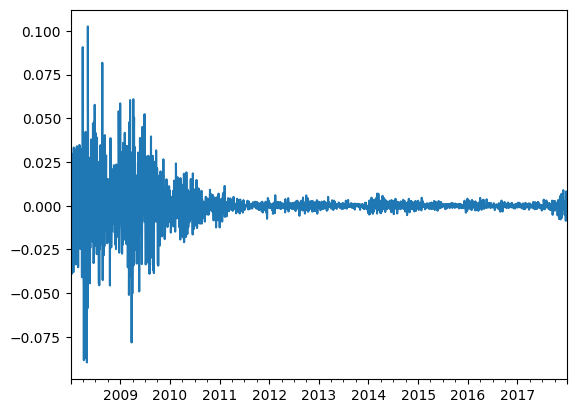

In [30]:
run = PairsTradingStrategy(corr_0.index[0], corr_0.index[3], df_stock_returns, 10, 50).run_strategy()

The Sharpe Ratio (Mean daily return normalised by stdev) = 0.563


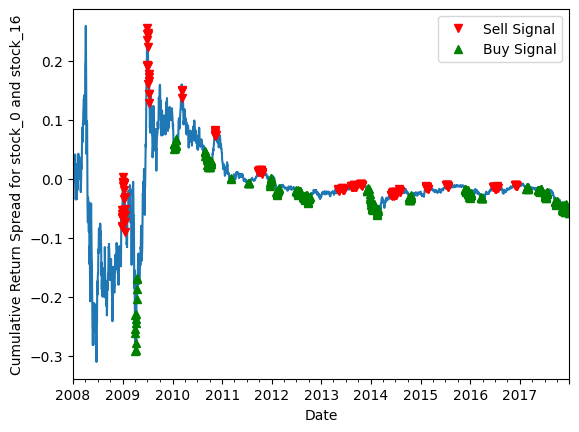

Text(0, 0.5, 'Rolling Sharpe Ratio')

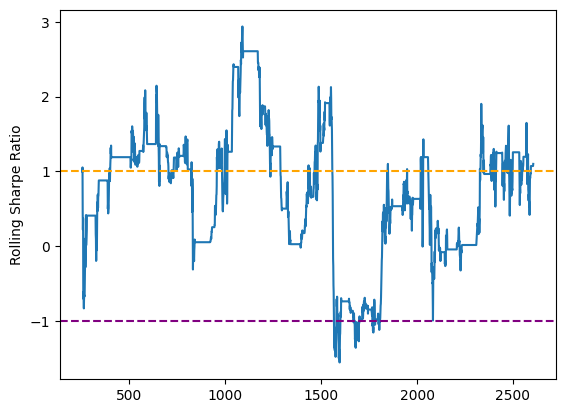

In [31]:
# Plotting the results from the pairs trading strategy
# First plot is the cumulative return spread between the stocks with the buy and sell signals overlaid
# Second plot is the rolling sharpe ratio of the strategy (252 day rolling window)

run[3].plot()
run[3][run [4] > 2].plot(color = 'red', label = 'Sell Signal', linestyle = 'None', marker = 'v')
run[3][run [4] < -2].plot(color = 'green', label = 'Buy Signal', linestyle = 'None', marker = '^')
plt.ylabel(f'Cumulative Return Spread for {corr_0.index[0]} and {corr_0.index[1]}')
plt.xlabel('Date')
plt.legend()

print(f'The Sharpe Ratio (Mean daily return normalised by stdev) = {run[0]:.3f}')
plt.show()

run[5].plot()
plt.axhline(1, color = 'orange', linestyle = '--')
plt.axhline(-1, color = 'purple', linestyle = '--')
plt.ylabel('Rolling Sharpe Ratio')

# Strategy 2: Mean Reversion Pairs Trading (ML Driven Approach)

In an attempt to increase the performance of the model, instead of just setting the model to long when Z < -2 and short when spread was Z > 2, I will create a Random Forest classifier that will take into account more features, train on a subset of the data and then test on the rest

Then we will backtest the ML model on the whole 10 year dataset

In [32]:
# Pairs Trading Strategy Class with Machine Learning
# This strategy trains on the rule based strategy and then uses a Random Forest Classifier to predict the signals
# The strategy will then back-test the model on the whole dataset
# The strategy will also plot the cumulative return spread, the Z-Score of the spread and the rolling Sharpe Ratio

class PairsTradingStrategy_ML:
    def __init__(self, stocka, stockb, df, window_s, window_l, entry_threshold = 2, exit_threshold = 1, plot = False, training_range = 0.8):
        self.stocka = stocka
        self.stockb = stockb
        self.df = df
        self.entry_threshold = entry_threshold
        self.exit_threshold = exit_threshold
        self.strategy_returns = []
        self.log_strategy_returns = []
        self.position = 0
        self.s_window = window_s
        self.l_window = window_l
        self.model = RandomForestClassifier(n_estimators=10, random_state=42, max_depth=5)
        self.plot = plot
        self.training_range = training_range
        self.eligibility_flag = True
        self.cumulative_df = self.cumulative_returns()

    def z_score(self, data):
        return (data - data.mean())/data.std()
    
    def diff_df(self, data = None):
        if data is None:
            data = self.df
        return data[self.stocka] - data[self.stockb]
    
    def cumulative_returns(self):
        return (1 + self.df).cumprod() - 1
    


    def eligibility_test(self):
        self.corr = self.cumulative_df[self.stocka].corr(self.cumulative_df[self.stockb])
        print(f'The correlation between {self.stocka} and {self.stockb} = {self.corr}')

        if self.corr < 0.8:
            print(f'Correlation of pair too low for mean reversion trading')
            self.eligibility_flag = False
            return self.eligibility_flag
        else:
            pass

        
        spread_ADF = adfuller(spread_df(self.cumulative_df, self.stocka, self.stockb))
        ratio_ADF = adfuller(self.cumulative_df[self.stocka]/self.cumulative_df[self.stockb])

        print(f'The p-value for the ADF test is {spread_ADF[1]} \nThe p-value for the ratio ADF test is {ratio_ADF[1]}')

        if spread_ADF[1] < 0.05:
            print(f'The spread is stationary between {self.stocka} and {self.stockb}')
        else:
            print(f'The spread is not stationary between {self.stocka} and {self.stockb}, cannot trade on this pair')
            self.eligibility_flag = False
            return self.eligibility_flag

        return self.eligibility_flag


    
    
    def generate_features(self):

        spread_df = self.cumulative_df[self.stocka] - self.cumulative_df[self.stockb]
        daily_changes = spread_df.diff().dropna()

        diff_MA = spread_df.rolling(window=self.s_window, closed = 'left').mean() - spread_df.rolling(window=self.l_window, closed = 'left').mean()
        std_50_MA = diff_MA.rolling(window=self.l_window, center = False).std()
        Z_score_MA = diff_MA/std_50_MA

        features = pd.DataFrame({
            'Z_score_MA': Z_score_MA,
            'Z_score_MA_lagged': Z_score_MA.shift(1),
            'short_MA': spread_df.rolling(window=self.s_window, closed = 'left').mean(),
            'long_MA': spread_df.rolling(window=self.l_window, closed = 'left').mean(),
            'volatility': spread_df.rolling(window=self.s_window, closed = 'left').std(),
        })

        self.no_nan = features.isnull().sum().max()
        features.dropna(inplace=True)

        return features
    
    def generate_labels(self, features):
        labels = []
        for i in range(0, len(features)):
            #print(len(features))
            if features['Z_score_MA'].iloc[i] > self.entry_threshold:
                labels.append(-1)
            elif features['Z_score_MA'].iloc[i] < -self.entry_threshold:
                labels.append(1)
            elif features['Z_score_MA'].iloc[i] < self.exit_threshold and features['Z_score_MA'].iloc[i] > -self.exit_threshold:
                labels.append(0)
            else:
                labels.append(labels[-1] if labels else 0)

        features['signal'] = labels
        features.dropna()


        return features
    

    def train_model(self):
        features = self.generate_features()
        labeled_features = self.generate_labels(features)

        X = labeled_features.drop('signal', axis=1)
        y = labeled_features['signal']
        # print(len(X), len(y))

        # Attempted training at the end and the start, but the model is not predicting correctly
        # Found that training in the middle of the dataset gives the best results
        split_point = int(len(features) * self.training_range)
        X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
        y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]


        self.model.fit(X_train, y_train)

        predictions = self.model.predict(X_test)
        accuracy = accuracy_score(y_test, predictions)
        test_score = self.model.score(X_test, y_test)
        train_score = self.model.score(X_train, y_train)

        print(f'The test score of the model is {test_score:.3f}')
        print(f'The train score of the model is {train_score:.3f}')



    def run_strategy(self):

        if self.eligibility_test() == False:
            return 0
        else:
            pass

        spread_df = cumulative_df[self.stocka] - cumulative_df[self.stockb]
        daily_changes = spread_df.diff().dropna()

        #spread_df_log = np.log(cumulative_df[self.stocka]+1e-2) - np.log(cumulative_df[self.stockb]+1e-2)
        #spread_df_log.plot()
        #log_daily_changes = spread_df_log.diff().dropna()

        print(len(daily_changes))
        # print(len(log_daily_changes))


        if not hasattr(self.model, 'model'):
            self.train_model()

        features = self.generate_features()

        # Back-testing the strategy on the whole dataset
        signals = self.model.predict(features.drop('signal', errors='ignore', axis=1))

        self.strategy_returns = []
        self.position = 0
        #print(len(signals))
        #print(len(spread_df))

        for i in range(1, len(features)):
            self.position = signals[i]
            self.strategy_returns.append(self.position * daily_changes.iloc[i])
            # self.log_strategy_returns.append(self.position * log_daily_changes.iloc[i])

        
        self.strategy_returns = pd.Series(self.strategy_returns)
        self.strategy_returns_test = pd.Series(self.strategy_returns[int(len(features) * self.training_range):])
        # self.log_strategy_returns = pd.Series(self.log_strategy_returns)
        self.std_strategy = self.strategy_returns.std()
        self.sharpe_ratio = (self.strategy_returns.mean()/self.std_strategy) * np.sqrt(252)
        self.sharpe_ratio_test = (self.strategy_returns_test.mean()/self.strategy_returns_test.std()) * np.sqrt(252)

        # One year rolling Sharpe Ratio
        self.rolling_sharpe_ratio = (self.strategy_returns.rolling(window=252).mean() / self.strategy_returns.rolling(window=252).std()) * np.sqrt(252)
        # self.rolling_sharpe_ratio_log = (self.log_strategy_returns.rolling(window=252).mean() / self.log_strategy_returns.rolling(window=252).std()) * np.sqrt(252)

        print(f'The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = {self.sharpe_ratio:.3f}')
        print(f'The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = {self.sharpe_ratio_test:.3f}')

        if self.plot:
            pd.Series(daily_changes).plot()
            plt.ylabel('Daily changes in spread (Cumulative Returns)')
            plt.show()

            spread_df.plot()
            spread_df.iloc[len(spread_df) - len(signals):][signals == -1].plot(color = 'red', 
                                                                               label = 'Sell Signal', 
                                                                               linestyle = 'None', 
                                                                               marker = 'v', 
                                                                               alpha = 0.5, 
                                                                               markersize = 5)
            
            spread_df.iloc[len(spread_df) - len(signals):][signals == 1].plot(color = 'green',
                                                                              label = 'Buy Signal', 
                                                                              linestyle = 'None', 
                                                                              marker = '^', 
                                                                              alpha = 0.5, 
                                                                              markersize = 5)
            #print(f'h{self.no_nan}')
            #print([int(len(features) * self.training_range)])
            #print(spread_df.index[int(len(features) * self.training_range)])
            plt.ylabel(f'Cumulative Return Spread for {self.stocka} and {self.stockb}')
            plt.axvline(spread_df.index[int(len(features) * self.training_range)], color='black', linestyle='--', linewidth=1, label="Train/Test Split")
            plt.axvspan(spread_df.index[0], spread_df.index[int(len(features) * self.training_range)], color='lightgrey', alpha=0.3)
            plt.axvspan(spread_df.index[0], spread_df.index[self.no_nan], color='darkgrey', alpha=0.3, label = 'NaN Values')
            plt.xlabel('Date')
            plt.legend()
            plt.show()

            Z_score_MA.plot()
            Z_score_MA.iloc[len(spread_df) - len(signals):][signals == -1].plot(color = 'red', 
                                                                               label = 'Sell Signal', 
                                                                               linestyle = 'None', 
                                                                               marker = 'v', 
                                                                               alpha = 0.5, 
                                                                               markersize = 2)
        
            Z_score_MA.iloc[len(spread_df) - len(signals):][signals == 1].plot(color = 'green',
                                                                                label = 'Buy Signal', 
                                                                                linestyle = 'None', 
                                                                                marker = '^', 
                                                                                alpha = 0.5, 
                                                                                markersize = 2)
            plt.axhline(1.5, color = 'red', linestyle = '--', label = 'Sell Threshold')
            plt.axhline(-1.5, color = 'green', linestyle = '--', label = 'Buy Threshold')
            plt.axhline(1, color = 'black', linestyle = '--', label = 'Exit Threshold')
            plt.axhline(-1, color = 'grey', linestyle = '--', label = 'Exit Threshold')
            plt.axhspan(-self.entry_threshold, self.entry_threshold, color='gray', alpha=0.2, label="No Trade Zone")
            plt.ylabel('Z-Score spread of 10-day vs 50-day moving averages')
            plt.legend(loc = 'lower right', fontsize = 'small')
            plt.show()

            self.rolling_sharpe_ratio.plot()
            plt.axhline(1, color = 'purple', linestyle = '--')
            plt.axhline(-1, color = 'orange', linestyle = '--')
            plt.ylabel('Rolling Sharpe Ratio for Cumulative Spread (1 year)')
            plt.show()

            #self.rolling_sharpe_ratio_log.plot()
            #plt.axhline(1, color = 'purple', linestyle = '--')
            #plt.axhline(-1, color = 'orange', linestyle = '--')
            #plt.ylabel('Rolling Sharpe Ratio for Log Spread (1 year)')
            #plt.show()

    

        return self.sharpe_ratio, self.strategy_returns, features, signals, cumulative_df[self.stocka] - cumulative_df[self.stockb], self.rolling_sharpe_ratio
    


## Results - Performance Metrics and Plots

The correlation between stock_0 and stock_73 = 0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73
2608
The test score of the model is 0.884
The train score of the model is 0.960
The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = 0.811
The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = 0.008


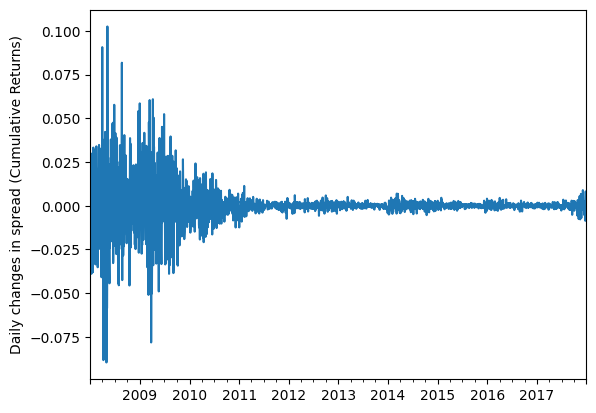

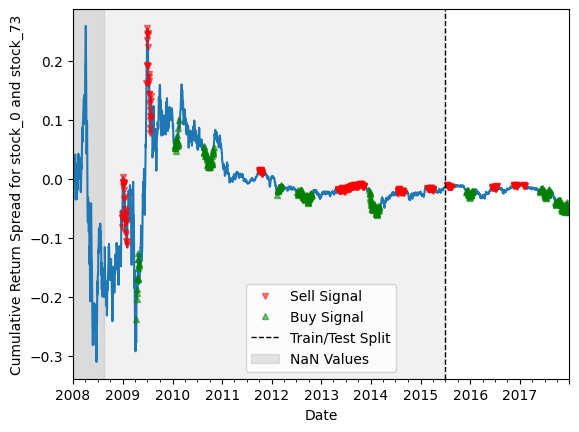

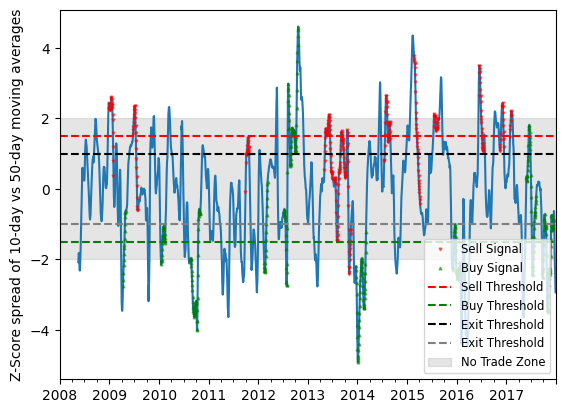

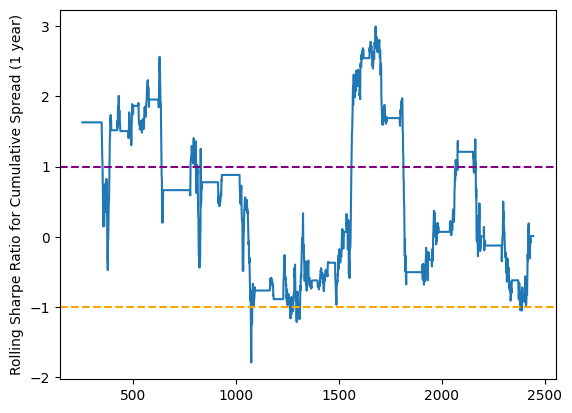

In [33]:
# The first plot is the daily chnages in the spread (cumulative returns) between the two stocks
# The second plot is the cumulative return spread between the two stocks with the buy and sell signals overlaid
# The third plot is the Z-Score of the spread between the 10 and 50 day moving averages of the cumulative return spread of the two stocks
# The fourth plot is the rolling Sharpe Ratio of the strategy (252 day rolling window)

test2 = PairsTradingStrategy_ML('stock_0', 'stock_73', df_stock_returns, 18, 81, plot=True).run_strategy()

## Optimisation engineering - Improve the performance 

- In the last model, we are using a simple random forest classifier that takes in features to do with the moving average and the volatility spread. We train on the labels set similary to the model in Section 2, and test on the rest.
- In this section we can briefly try to optimise for the MA window size and the entry and exit thresholds.

Testing ideas

In [34]:

PairsTradingStrategy_ML('stock_0', 'stock_73', df_stock_returns, 10, 30, plot=False).run_strategy()[0]

The correlation between stock_0 and stock_73 = 0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73
2608
The test score of the model is 0.896
The train score of the model is 0.972
The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = 0.363
The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = 0.571


0.362996132219212

In [35]:
# This function will optimise the window sizes for the moving averages of the cumulative return spread of two stocks
# It uses a simple brute force method to find the best window sizes that maximise the Sharpe Ratio of the strategy

def optimise_window_sizes(stocka, stockb, df, entry_threshold = 2, exit_threshold = 1):
    best_sharpe = 0
    best_window_s = 0
    best_window_l = 0

    for i in range(5, 20):
        for j in range(70, 100):
            try:
                strategy = PairsTradingStrategy_ML(stocka, stockb, df, i, j)
                sharpe = strategy.run_strategy()[0]
                if sharpe > best_sharpe:
                    best_sharpe = sharpe
                    best_window_s = i
                    best_window_l = j
            except:
                pass

    return best_sharpe, best_window_s, best_window_l

In [36]:
# Find the optimal window sizes for the moving averages of the cumulative return spread of stock_0 and stock_73

optimised_windows = optimise_window_sizes('stock_0', 'stock_73', df_stock_returns)

The correlation between stock_0 and stock_73 = 0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73
2608
The test score of the model is 0.816
The train score of the model is 0.962
The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = -0.535
The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = 0.192
The correlation between stock_0 and stock_73 = 0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73
2608
The test score of the model is 0.830
The train score of the model is 0.953
The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = -0.508
The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = 0.631
The correlation between st

In [37]:
PairsTradingStrategy_ML('stock_0', 'stock_73', df_stock_returns, 18, 81, plot=False).run_strategy()

The correlation between stock_0 and stock_73 = 0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73
2608
The test score of the model is 0.884
The train score of the model is 0.960
The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = 0.811
The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = 0.008


(0.8111698460763402,
 0       0.0
 1       0.0
 2       0.0
 3      -0.0
 4       0.0
        ... 
 2441   -0.0
 2442   -0.0
 2443    0.0
 2444    0.0
 2445   -0.0
 Length: 2446, dtype: float64,
             Z_score_MA  Z_score_MA_lagged  short_MA   long_MA  volatility
 2008-08-14    0.145165           0.197300 -0.154570 -0.166418    0.037423
 2008-08-15    0.117794           0.145165 -0.158319 -0.167881    0.034330
 2008-08-18    0.073558           0.117794 -0.163371 -0.169326    0.029881
 2008-08-19    0.034876           0.073558 -0.167619 -0.170441    0.026011
 2008-08-20   -0.010040           0.034876 -0.173008 -0.172194    0.021730
 ...                ...                ...       ...       ...         ...
 2017-12-25   -1.699867          -1.620468 -0.049097 -0.042712    0.006040
 2017-12-26   -1.759215          -1.699867 -0.049490 -0.043132    0.006543
 2017-12-27   -1.680880          -1.759215 -0.049303 -0.043453    0.006404
 2017-12-28   -1.699436          -1.680880 -0.049556 -0

In [38]:
# This function will optimise the entry threshold for the strategy
# It uses a simple brute force method to find the best entry threshold that maximises the Sharpe Ratio of the strategy

def optimise_entry_threshold(stocka, stockb, df, window_s, window_l):
    best_sharpe = 0
    best_entry = 0

    for i in np.linspace(1, 3, 20):
        try:
            strategy = PairsTradingStrategy_ML(stocka, stockb, df, window_s, window_l, entry_threshold = i)
            sharpe = strategy.run_strategy()[0]
            if sharpe > best_sharpe:
                best_sharpe = sharpe
                best_entry = i
        except:
            pass

    return best_sharpe, best_entry

In [39]:
# Find the optimal entry threshold for the strategy, given the optimal window sizes

optimised_entry = optimise_entry_threshold('stock_0', 'stock_73', df_stock_returns, 18, 81)

The correlation between stock_0 and stock_73 = 0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73
2608
The test score of the model is 0.998
The train score of the model is 0.999
The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = 0.514
The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = 0.256
The correlation between stock_0 and stock_73 = 0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73
2608
The test score of the model is 0.965
The train score of the model is 0.998
The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = 0.441
The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = 0.507
The correlation between stoc

In [40]:
optimised_entry

(0.857406894892421, 1.736842105263158)

In [41]:
PairsTradingStrategy_ML('stock_0', 'stock_73', df_stock_returns, 18, 81, entry_threshold=2.14, plot=False).run_strategy()

The correlation between stock_0 and stock_73 = 0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73
2608
The test score of the model is 0.841
The train score of the model is 0.965
The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = 0.759
The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = 0.193


(0.7593726293137365,
 0       0.0
 1       0.0
 2       0.0
 3      -0.0
 4       0.0
        ... 
 2441   -0.0
 2442   -0.0
 2443    0.0
 2444    0.0
 2445   -0.0
 Length: 2446, dtype: float64,
             Z_score_MA  Z_score_MA_lagged  short_MA   long_MA  volatility
 2008-08-14    0.145165           0.197300 -0.154570 -0.166418    0.037423
 2008-08-15    0.117794           0.145165 -0.158319 -0.167881    0.034330
 2008-08-18    0.073558           0.117794 -0.163371 -0.169326    0.029881
 2008-08-19    0.034876           0.073558 -0.167619 -0.170441    0.026011
 2008-08-20   -0.010040           0.034876 -0.173008 -0.172194    0.021730
 ...                ...                ...       ...       ...         ...
 2017-12-25   -1.699867          -1.620468 -0.049097 -0.042712    0.006040
 2017-12-26   -1.759215          -1.699867 -0.049490 -0.043132    0.006543
 2017-12-27   -1.680880          -1.759215 -0.049303 -0.043453    0.006404
 2017-12-28   -1.699436          -1.680880 -0.049556 -0

In [42]:
# This function will optimise the exit threshold for the strategy
# It uses a simple brute force method to find the best exit threshold that maximises the Sharpe Ratio of the strategy

def optimise_exit_threshold(stocka, stockb, df, window_s, window_l, entry_threshold):
    best_sharpe = 0
    best_entry = 0

    for i in np.linspace(0, 2, 20):
        try:
            strategy = PairsTradingStrategy_ML(stocka, stockb, df, window_s, window_l, entry_threshold, exit_threshold = i)
            sharpe = strategy.run_strategy()[0]
            if sharpe > best_sharpe:
                best_sharpe = sharpe
                best_exit = i
        except:
            pass

    return best_sharpe, best_exit

In [43]:
# Find the optimal exit threshold for the strategy, given the optimal window sizes and entry threshold

optimise_exit_threshold('stock_0', 'stock_73', df_stock_returns, 18, 81, 2.14)

The correlation between stock_0 and stock_73 = 0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73
2608
The test score of the model is 0.380
The train score of the model is 0.902
The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = 0.093
The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = 0.148
The correlation between stock_0 and stock_73 = 0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73
2608
The test score of the model is 0.657
The train score of the model is 0.843
The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = 0.512
The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = -0.604
The correlation between sto

(0.7823085391424716, 0.9473684210526315)

Making the optimisation one function

In [44]:
# Testing the optimisation method using initial parameter guesses

init_params = [20, 70, 2, 1]

swindow, lwindow, entry, exit = int(init_params[0]), int(init_params[1]), init_params[2], init_params[3]

sharpe_ratio = -PairsTradingStrategy_ML('stock_0', 'stock_73', df_stock_returns, swindow, lwindow, entry_threshold=entry, exit_threshold=exit).run_strategy()[0]

bounds = [(5, 30), (30, 100), (1, 3), (0.5, 2)]

result = minimize(lambda x: -PairsTradingStrategy_ML('stock_0', 'stock_73', df_stock_returns, int(x[0]), int(x[1]), entry_threshold=x[2], exit_threshold=x[3]).run_strategy()[0], init_params, method='Powell', bounds=bounds)

The correlation between stock_0 and stock_73 = 0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73
2608
The test score of the model is 0.889
The train score of the model is 0.971
The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = -0.189
The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = -0.409
The correlation between stock_0 and stock_73 = 0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73
2608
The test score of the model is 0.889
The train score of the model is 0.971
The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = -0.189
The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = -0.409
The correlation between 

In [45]:
# printing the results of the optimisation

result.x[0], result.x[1], result.x[2], result.x[3], -result.fun

(20.417490746514257,
 45.58522207659762,
 2.2078535825445673,
 0.9377279123791709,
 0.3937151987201861)

Seems like at a basic level, the manual univaraite minimiser is working better, so lets stick with that

In [46]:
# Combining all the above functions into a single optimisation function
# This function finds good the window sizes, entry threshold and exit threshold for the strategy
# It uses a simple brute force method to find the best parameters that maximise the Sharpe Ratio of the strategy in one run
# In reality a much more complex minimisation method should be employed to find the true global minmum of the negative sharpe function (multiple runs/more sophisticated methods)

def manual_univariate_optimiser(stocka, stockb, df):
    best_sharpe = 0
    best_window_s = 0
    best_window_l = 0

    for i in range(10, 20):
        for j in range(70, 90):
            try:
                strategy = PairsTradingStrategy_ML(stocka, stockb, df, i, j)
                sharpe = strategy.run_strategy()[0]
                if sharpe > best_sharpe:
                    best_sharpe = sharpe
                    best_window_s = i
                    best_window_l = j
            except:
                pass

    best_entry = 0

    for i in np.linspace(1, 3, 50):
        try:
            strategy = PairsTradingStrategy_ML(stocka, stockb, df, best_window_s, best_window_l, entry_threshold = i)
            sharpe = strategy.run_strategy()[0]
            if sharpe >= best_sharpe:
                best_sharpe = sharpe
                best_entry = i
        except:
            pass

    best_exit = 0

    for i in np.linspace(0.2, 2, 50):
        try:
            strategy = PairsTradingStrategy_ML(stocka, stockb, df, best_window_s, best_window_l, entry_threshold=best_entry, exit_threshold = i)
            sharpe = strategy.run_strategy()[0]
            if sharpe >= best_sharpe:
                best_sharpe = sharpe
                best_exit = i
        except:
            pass


    return best_sharpe, best_window_s, best_window_l, best_entry, best_exit

In [47]:
# Running the optimisation function
# Note: This function may take a couple of minutes to run

test = manual_univariate_optimiser('stock_0', 'stock_73', df_stock_returns)

The correlation between stock_0 and stock_73 = 0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73
2608
The test score of the model is 0.860
The train score of the model is 0.962
The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = -0.588
The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = 0.595
The correlation between stock_0 and stock_73 = 0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73
2608
The test score of the model is 0.885
The train score of the model is 0.959
The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = -0.677
The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = 0.610
The correlation between st

The correlation between stock_0 and stock_73 = 0.9747171039229643
The p-value for the ADF test is 0.000593639177517684 
The p-value for the ratio ADF test is 1.4054131038668414e-22
The spread is stationary between stock_0 and stock_73
2608
The test score of the model is 0.912
The train score of the model is 0.967
The Sharpe Ratio for the 10 Y (Mean daily return normalised by stdev) = 0.975
The Sharpe Ratio for the Test Period (2.5 Y) (Mean daily return normalised by stdev) = 0.986


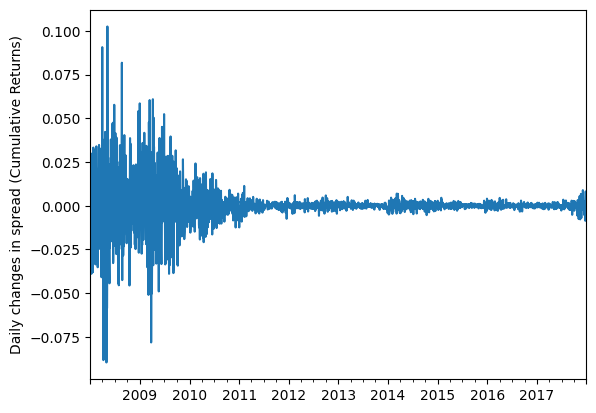

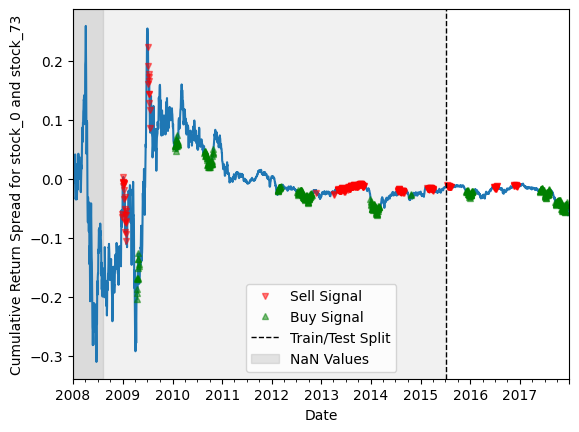

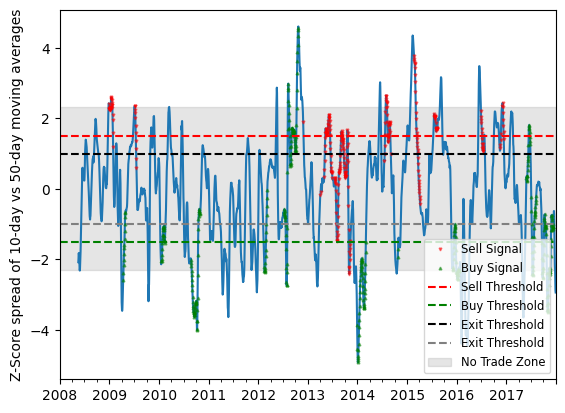

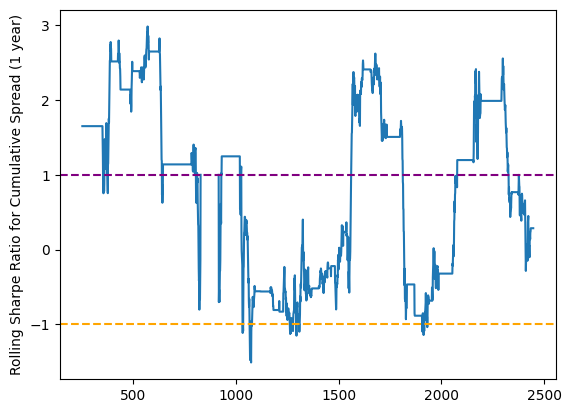

(0.9752507634767682,
 0       0.0
 1       0.0
 2       0.0
 3      -0.0
 4       0.0
        ... 
 2443    0.0
 2444    0.0
 2445   -0.0
 2446   -0.0
 2447    0.0
 Length: 2448, dtype: float64,
             Z_score_MA  Z_score_MA_lagged  short_MA   long_MA  volatility
 2008-08-12    0.212317           0.228693 -0.147055 -0.164647    0.041689
 2008-08-13    0.162238           0.212317 -0.152834 -0.166197    0.037819
 2008-08-14    0.120157           0.162238 -0.158089 -0.167952    0.035373
 2008-08-15    0.082680           0.120157 -0.162416 -0.169197    0.030516
 2008-08-18    0.041580           0.082680 -0.166909 -0.170325    0.026632
 ...                ...                ...       ...       ...         ...
 2017-12-25   -1.637925          -1.562762 -0.048845 -0.042916    0.006127
 2017-12-26   -1.659063          -1.637925 -0.049129 -0.043343    0.006557
 2017-12-27   -1.584702          -1.659063 -0.049002 -0.043671    0.006469
 2017-12-28   -1.567936          -1.584702 -0.049154 -0

In [48]:
# Running the strategy with the optimised parameters 
# The strategy will plot the cumulative return spread, the Z-Score of the spread and the rolling Sharpe Ratio

PairsTradingStrategy_ML('stock_0', 'stock_73', df_stock_returns, test[1], test[2], entry_threshold=test[3], exit_threshold=test[4], plot=True).run_strategy()

# Strategy 3: Events Driven Trading (Rule-Based)

- In this section i will attempt to develop a strategy based around events.
- The general idea is to train a simple classification model on what usually happens around events for each stock
- Then test on the remainder of the upcoming events
- A good model would take into account the time relative to the event, the volatility, the MA and more

### Setting up and testing ideas

In [49]:
# Printing the dates of the events for stock_x

event_dates = df_events[df_events['stock_1'] == 1].index
event_dates

DatetimeIndex(['2008-01-29', '2008-04-22', '2008-06-27', '2008-09-15',
               '2008-12-31', '2009-03-26', '2009-06-12', '2009-08-11',
               '2009-12-14', '2010-01-26', '2010-04-28', '2010-07-26',
               '2010-11-08', '2011-01-25', '2011-03-29', '2011-06-27',
               '2011-09-13', '2011-12-27', '2012-03-13', '2012-06-22',
               '2012-09-06', '2012-11-07', '2013-02-26', '2013-05-22',
               '2013-08-02', '2013-11-04', '2014-02-03', '2014-04-24',
               '2014-07-17', '2014-09-04', '2014-12-18', '2015-03-27',
               '2015-05-19', '2015-09-02', '2015-11-20', '2016-02-26',
               '2016-04-21', '2016-07-11', '2016-10-03', '2016-12-21',
               '2017-04-19', '2017-07-10', '2017-08-31', '2017-12-06'],
              dtype='datetime64[ns]', freq=None)

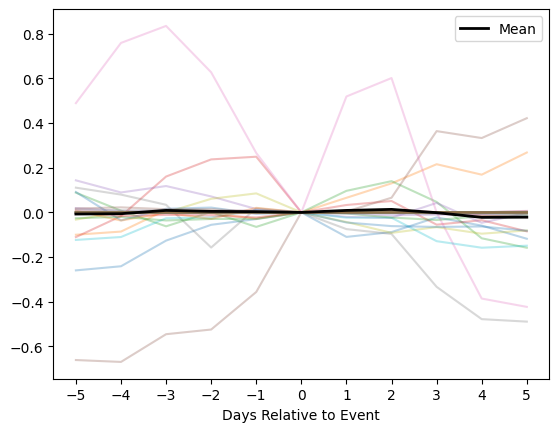

In [50]:
# Plotting the reaction of the stock cumulative returns centered around the event dates
# The plot shows the cumulative returns of the stock 5 days before and after the event date for all event dates
# The expected mean reaction is the black line

cumulative_df = (1 + df_stock_returns).cumprod() - 1

all_windows = []
for i in range(0, len(event_dates)):
    window = cumulative_df['stock_1'].loc[event_dates[i] - pd.offsets.BDay(5) : event_dates[i] + pd.offsets.BDay(5)]
    if len(window) == 11:
        window_normalized = window - window.iloc[5]
        all_windows.append(window_normalized.values)
        plt.plot(range(-5, 6), window_normalized.values, alpha = 0.3)

plt.plot(range(-5, 6), np.mean(all_windows, axis=0), color = 'black', linewidth = 2, label = 'Mean')
plt.xticks(ticks=range(-5, 6))
plt.xlabel("Days Relative to Event")
plt.legend()

In [51]:
all_windows = np.array(all_windows)
mean_window = np.mean(all_windows, axis=0)
mean_window

array([-0.00737045, -0.00585864,  0.00892611,  0.00459051,  0.00320519,
        0.        ,  0.00882106,  0.01342066, -0.00130705, -0.02229225,
       -0.02136348])

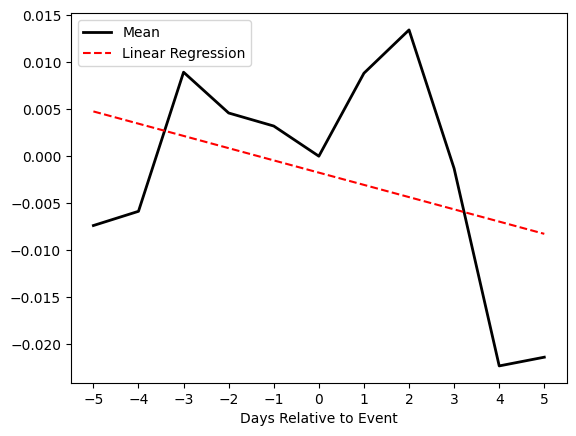

In [52]:
# Plotting the mean expected reaction of the stock to the event
# Fitting a one dimensional regression to the expected reaction

X = np.array(range(-5, 6)).reshape(-1, 1)
y = mean_window

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

plt.plot(range(-5, 6), mean_window, color = 'black', linewidth = 2, label = 'Mean')
plt.plot(range(-5, 6), predictions, color = 'red', linestyle = '--', label = 'Linear Regression')
plt.xticks(ticks=range(-5, 6))
plt.xlabel("Days Relative to Event")
plt.legend()

Clearly we need a polynomial model. Then we fit and predict based on the polynomial.

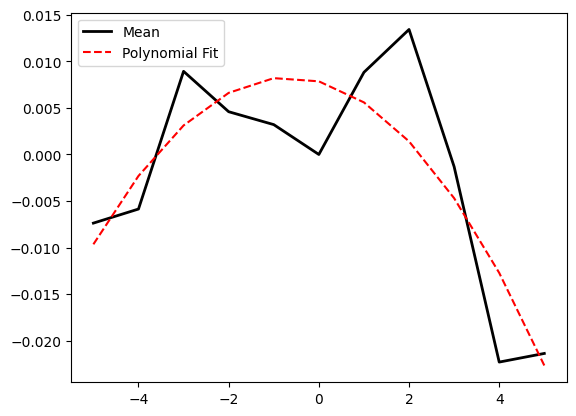

In [53]:
# Fitting a two dimensional polynomial regression to the expected reaction

polynomial_model = PolynomialFeatures(degree = 2)
X_poly = polynomial_model.fit_transform(X)

model_p = LinearRegression()
model_p.fit(X_poly, y)

y_pred = model_p.predict(X_poly)

plt.plot(range(-5,6), mean_window, color = 'black', linewidth = 2, label = 'Mean')
plt.plot(range(-5,6), y_pred, 'red', linestyle = '--', label = 'Polynomial Fit')
plt.legend()


### Rule-Based Model

In [54]:
# Event driven trading strategy class using a rule based strategy
# If the coefficient of the quadratic term is positive, the strategy will buy when the event occurs and sell at the edges of the polynomial
# If the coefficient of the quadratic term is negative, the strategy will sell when the event occurs and buy at the edges of the polynomial
# First the strategy will check if the RMSE of the polynomial is below a certain threshold
# Then the strategy will plot the cumulative returns of the stock and the buy and sell signals


class EventsTradingStrategy:
    def __init__(self, stocka, df, event_df, window, plot = False, rmse_threshold = 0.01):
        self.stocka = stocka
        self.df = df
        self.event_df = event_df
        self.strategy_returns = []
        self.position = 0
        self.window = window
        self.plot = plot
        self.rmse_threshold = rmse_threshold

    def z_score(self, data):
        return (data - data.mean())/data.std()
    
    def cumulative_returns(self):
        return (1 + self.df).cumprod() - 1
    

    def run_strategy(self, poly):
        print(poly)
        coeff_a, coeff_b, coeff_c = poly

        # plt.plot(np.linspace(-5,5,100), coeff_a + coeff_b * np.linspace(-5,5,100) + coeff_c * np.linspace(-5,5,100)**2, color = 'green', label = 'Interpolation')

        self.position = 0

        min_date = - (coeff_b/((2*coeff_c)+1e-7))
        min_date_rounded = np.round(min_date, 1)
        min_date_int = int(min_date_rounded)

        print(min_date_int)

        signal = [0] * len(self.df)

        if coeff_c > 0:
            for i in range(0, len(self.df)):
                if self.event_df[self.stocka].iloc[i] == 0:
                    pass
                else:
                    if i < self.window or len(self.df) - i < self.window:
                        pass
                    else:
                        #print(int(i + min_date))
                        signal[int(i + min_date)+1] = 1
                        signal[int(i + min_date + self.window)+1] = -1
                        signal[int(i + min_date - self.window)+1] = -1

        elif coeff_c < 0:
            for i in range(0, len(self.df)):
                if self.event_df[self.stocka].iloc[i] == 0:
                    pass
                else:
                    if i < self.window or len(self.df) - i < self.window:
                        pass
                    else:
                        #print(int(i + min_date))
                        signal[int(i + min_date)] = -1
                        signal[int(i + min_date + self.window)] = +1
                        signal[int(i + min_date - self.window)] = +1

        # Run the strategy
        cumulative_df = self.cumulative_returns()
        daily_changes = cumulative_df[self.stocka].diff().dropna()

        #print(len(daily_changes))

        self.position = 0
        self.strategy_returns = []

        for i in range(0, len(daily_changes)):
            self.position = signal[i]
            self.strategy_returns.append(self.position * daily_changes.iloc[i])


        if self.plot:
            # pd.Series(self.strategy_returns).plot()
            plt.show()

        signals = pd.Series(signal, index = cumulative_df.index)

        #print(len(signals))
        #print(len(cumulative_df))

        strategy_returns_series = pd.Series(self.strategy_returns)
        sharpe_ratio = (strategy_returns_series.mean() / strategy_returns_series.std()) * np.sqrt(252)
        rolling_sharpe_ratio = (strategy_returns_series.rolling(window = 252).mean() / strategy_returns_series.rolling(window = 252).std()) * np.sqrt(252)

        if self.plot:
            cumulative_df[self.stocka].plot()
            (cumulative_df[self.stocka])[signals == +1].plot(color = 'green',
                                                            label = 'Buy Signal', 
                                                            linestyle = 'None', 
                                                            marker = '^', 
                                                            alpha = 0.5, 
                                                            markersize = 5)
            (cumulative_df[self.stocka])[signals == -1].plot(color = 'red',
                                                            label = 'Sell Signal', 
                                                            linestyle = 'None', 
                                                            marker = 'v', 
                                                            alpha = 0.5, 
                                                            markersize = 5)
            plt.legend()
            plt.show()

            cumulative_df[self.stocka].iloc[-252:].plot()
            (cumulative_df[self.stocka].iloc[-252:])[signals == +1].plot(color = 'green',
                                                            label = 'Buy Signal', 
                                                            linestyle = 'None', 
                                                            marker = '^', 
                                                            alpha = 0.5, 
                                                            markersize = 5)
            (cumulative_df[self.stocka].iloc[-252:])[signals == -1].plot(color = 'red',
                                                            label = 'Sell Signal', 
                                                            linestyle = 'None', 
                                                            marker = 'v', 
                                                            alpha = 0.5, 
                                                            markersize = 5)
            print( (cumulative_df[self.stocka].iloc[-252:])[signals == - 1].index[1] )
            for i in range(len((cumulative_df[self.stocka].iloc[-252:])[signals == + 1])):
                plt.axvline((cumulative_df[self.stocka].iloc[-252:])[signals == + 1].index[i], color='black', linestyle='--', linewidth=1)
            plt.legend()
            plt.xlabel('2017')
            plt.ylabel('Cumulative Returns')                     
            plt.legend()
            plt.show()
 
            rolling_sharpe_ratio.plot()
            plt.axhline(1, linestyle = '--', color = 'purple')
            plt.axhline(-1, linestyle = '--', color = 'orange')
            plt.ylabel
            plt.xticks(ticks = range(0, len(rolling_sharpe_ratio), 252))
            plt.show()


        print(f'The Sharpe Ratio is {sharpe_ratio:.3f}')
        print(f'The average daily cumulative return is {strategy_returns_series.mean():.6f}')

        return sharpe_ratio, strategy_returns_series.mean(), rolling_sharpe_ratio

    
    def regression_test(self):
        cumulative_df = self.cumulative_returns()
        all_windows = []
        event_dates = self.event_df[self.event_df[self.stocka] == 1].index

        # print(event_dates)

        for i in range(0, len(event_dates)):
            window = cumulative_df[self.stocka].loc[event_dates[i] - pd.offsets.BDay(self.window) : event_dates[i] + pd.offsets.BDay(self.window)]
            if len(window) == int(2*self.window + 1):
                window_normalized = window - window.iloc[self.window]
                all_windows.append(window_normalized.values)
                if self.plot:
                    plt.plot(range(-self.window, self.window+1), window_normalized.values, alpha = 0.3)

        if self.plot:
            plt.plot(range(-self.window, self.window+1), np.mean(all_windows, axis=0), color = 'black', linewidth = 2, label = 'Mean')
            plt.xticks(ticks= range(-self.window, self.window+1))
            plt.xlabel("Days Relative to Event")
            plt.legend()
            plt.show()

        all_windows = np.array(all_windows)
        mean_window = np.mean(all_windows, axis=0)

        X = np.array(range(-self.window, self.window+1)).reshape(-1, 1)
        y = mean_window

        polynomial_model = PolynomialFeatures(degree = 2)
        X_poly = polynomial_model.fit_transform(X)

        model_p = LinearRegression()
        model_p.fit(X_poly, y)

        y_pred = model_p.predict(X_poly)

        rmse = root_mean_squared_error(y, y_pred)

        if self.plot:
            plt.plot(range(-self.window, self.window+1), mean_window, color = 'black', linewidth = 2, label = 'Mean')
            plt.plot(range(-self.window, self.window+1), y_pred, 'red', linestyle = '--', label = 'Regression')
            plt.plot(np.linspace(-self.window,self.window,100), model_p.predict(polynomial_model.fit_transform(np.linspace(-self.window,self.window,100).reshape(-1, 1))), color = 'green', label = 'Interpolation')
            plt.xticks(ticks=range(-self.window, self.window+1))
            plt.xlabel("Days Relative to Event")
            plt.legend()
            plt.show()
        print(f'The Root Mean Squared Error is {rmse:.3f}')

        if rmse <= self.rmse_threshold:
            self.run_strategy(model_p.coef_)
            
        else:
            print('The RMSE is too high for a trade to be made')


## Results - Performance and Metrics

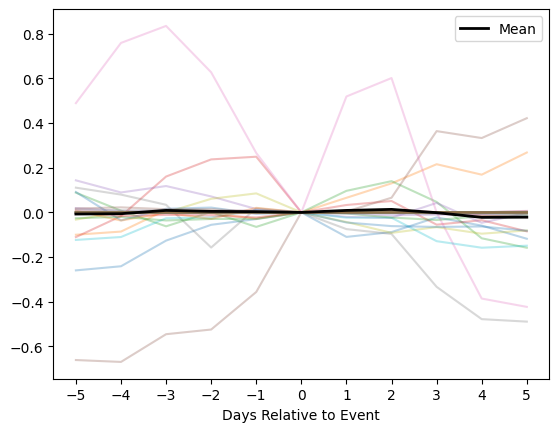

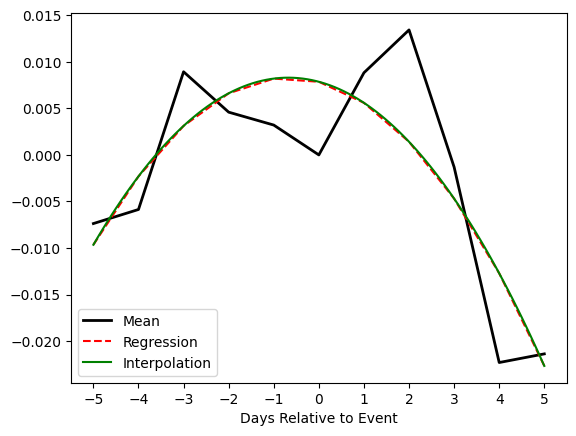

The Root Mean Squared Error is 0.006
[ 0.         -0.00130112 -0.00096018]
0


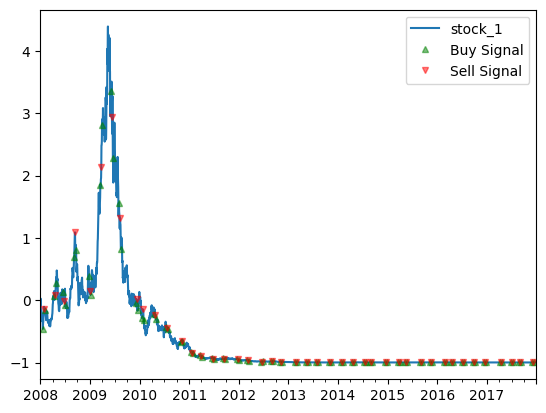

2017-07-07 00:00:00


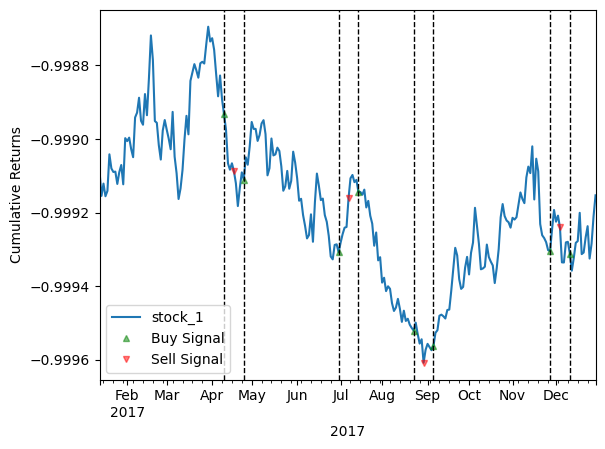

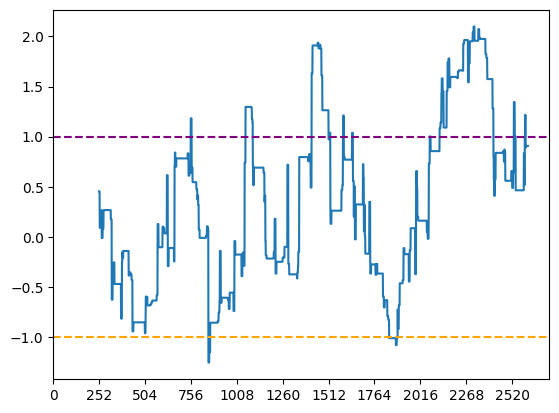

The Sharpe Ratio is -0.111
The average daily cumulative return is -0.000087


In [55]:
# Running the event driven trading strategy on stock_1 with a 5 day window
# First plot: The changes returns around the event dates
# Second plot: polynomial regression of the expected reaction to the event
# Third plot: Cumulative returns of the stock with the buy and sell signals overlaid
# Fourth plot: Last year of the cumulative returns with dashed lines around the buy and sell signals
# Fifth plot: Rolling Sharpe Ratio of the strategy

EventsTradingStrategy('stock_1', df_stock_returns, df_events, 5, plot=True).regression_test()

# Strategy 4: Events Driven Trading Model (ML Approach)

In [56]:
# Event driven trading strategy class using a machine learning model
# The strategy will train a Random Forest Classifier on the rule based strategy and then back-test the model on the whole dataset
# The strategy will also plot the cumulative return spread, the Z-Score of the spread and the rolling Sharpe Ratio

class EventsTradingStrategy_ML:
    def __init__(self, stocka, df, event_df, window, plot = False, rmse_threshold = 0.01, training_window = 10):
        self.stocka = stocka
        self.df = df
        self.event_df = event_df
        self.strategy_returns = []
        self.position = 0
        self.window = window
        self.plot = plot
        self.rmse_threshold = rmse_threshold
        self.training_window = training_window

    def z_score(self, data):
        return (data - data.mean())/data.std()
    
    def cumulative_returns(self):
        return (1 + self.df).cumprod() - 1
    

    def regression_test(self):
        cumulative_df = self.cumulative_returns()
        all_windows = []
        event_dates = self.event_df[self.event_df[self.stocka] == 1].index

        # print(event_dates)

        for i in range(0, len(event_dates)):
            window = cumulative_df[self.stocka].loc[event_dates[i] - pd.offsets.BDay(self.window) : event_dates[i] + pd.offsets.BDay(self.window)]
            if len(window) == int(2*self.window + 1):
                window_normalized = window - window.iloc[self.window]
                all_windows.append(window_normalized.values)
                if self.plot:
                    plt.plot(range(-self.window, self.window+1), window_normalized.values, alpha = 0.3)

        if self.plot:
            plt.plot(range(-self.window, self.window+1), np.mean(all_windows, axis=0), color = 'black', linewidth = 2, label = 'Mean')
            plt.xticks(ticks= range(-self.window, self.window+1))
            plt.xlabel("Days Relative to Event")
            plt.legend()
            plt.show()

        all_windows = np.array(all_windows)
        mean_window = np.mean(all_windows, axis=0)

        X = np.array(range(-self.window, self.window+1)).reshape(-1, 1)
        y = mean_window

        polynomial_model = PolynomialFeatures(degree = 2)
        X_poly = polynomial_model.fit_transform(X)

        model_p = LinearRegression()
        model_p.fit(X_poly, y)

        y_pred = model_p.predict(X_poly)

        rmse = root_mean_squared_error(y, y_pred)
        print(model_p.coef_)

        if self.plot:
            plt.plot(range(-self.window, self.window+1), mean_window, color = 'black', linewidth = 2, label = 'Mean')
            plt.plot(range(-self.window, self.window+1), y_pred, 'red', linestyle = '--', label = 'Regression')
            plt.plot(np.linspace(-self.window,self.window,100), model_p.predict(polynomial_model.fit_transform(np.linspace(-self.window,self.window,100).reshape(-1, 1))), color = 'green', label = 'Interpolation')
            plt.xticks(ticks=range(-self.window, self.window+1))
            plt.xlabel("Days Relative to Event")
            plt.legend()
            plt.show()
        print(f'The Root Mean Squared Error is {rmse:.3f}')

        if rmse <= self.rmse_threshold:
            self.run_strategy(model_p.coef_)
            
        else:
            print('The RMSE is too high for a trade to be made')

    
    def generate_features(self):
        self.cumulative_df = self.cumulative_returns()

        features = pd.DataFrame({
            'volatility': self.cumulative_df[self.stocka].rolling(window = self.training_window, closed = 'left').std().shift(1),
            'short_MA': self.cumulative_df[self.stocka].rolling(window = self.training_window, closed = 'left').mean().shift(1),
            'long_MA': self.cumulative_df[self.stocka].rolling(window = 5*self.training_window, closed = 'left').mean().shift(1),
        })

        self.no_nan = features.isnull().sum().max()
        features.dropna(inplace=True)

        return features
    





    def generate_labels(self, features, poly):
        coeff_a, coeff_b, coeff_c = poly
        self.position = 0

        min_date = - (coeff_b/((2*coeff_c)+1e-7))
        min_date_rounded = np.round(min_date, 1)
        min_date_int = int(min_date_rounded)

        # print(min_date_int)

        signal = [0] * len(self.df)


        if coeff_c > 0:
            for i in range(0, len(self.df)):
                if self.event_df[self.stocka].iloc[i] == 0:
                    pass
                else:
                    if i < self.window or len(self.df) - i < self.window:
                        pass
                    else:
                        # print(int(i + min_date))
                        signal[int(i + min_date)+1] = 1
                        signal[int(i + min_date + self.window)+1] = -1
                        signal[int(i + min_date - self.window)+1] = -1

        elif coeff_c < 0:
            for i in range(0, len(self.df)):
                if self.event_df[self.stocka].iloc[i] == 0:
                    pass
                else:
                    if i < self.window or len(self.df) - i < self.window:
                        pass
                    else:
                        # print(int(i + min_date))
                        signal[int(i + min_date)] = -1
                        signal[int(i + min_date + self.window)] = +1
                        signal[int(i + min_date - self.window)] = +1

        

        # print(features.isna().sum())
        #print(signal[100:300])
        features['signal'] = signal[self.no_nan:]

        # print(features['signal'].value_counts())

        return features
    

    # Validation of the model
    def train_model(self):

        features = self.generate_features()
        labeled_features = self.generate_labels(features, model_p.coef_)
        #print(labeled_features)
        labeled_features.dropna(inplace=True)
        X = labeled_features.drop('signal', axis=1)
        y = labeled_features['signal']

        split_point = int(len(features) * 0.8)
        X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
        y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

        self.model = RandomForestClassifier(n_estimators=20, random_state=42, max_depth=3, class_weight='balanced')
        self.model.fit(X_train, y_train)

        predictions = self.model.predict(X_test)
        test_score = self.model.score(X_test, y_test)
        train_score = self.model.score(X_train, y_train)

        print(f'The test score of the model is {test_score:.3f}')
        print(f'The train score of the model is {train_score:.3f}')



    def run_strategy(self, poly):

        features = self.generate_features()
        labels = self.generate_labels(features, model_p.coef_)

        if not hasattr(self, 'model'):
            self.train_model()

        # Back-testing the strategy on the whole dataset

        signals = self.model.predict(features.drop('signal', errors='ignore', axis=1))

        self.strategy_returns = []
        self.position = 0

        for i in range(0, len(features)):
            self.position = signals[i]
            self.strategy_returns.append(self.position * self.cumulative_df[self.stocka].iloc[i])


        #print(self.strategy_returns)
        #print(signals[20:50])
        strategy_returns = pd.Series(self.strategy_returns)

        std_strategy = strategy_returns.std()

        self.sharpe_ratio = (strategy_returns.mean()/std_strategy) * np.sqrt(252)
        self.roll_sharpe_ratio = (strategy_returns.rolling(window=252).mean() / strategy_returns.rolling(window=252).std()) * np.sqrt(252)



        labels_series = pd.Series(signals, index = self.cumulative_df.index[self.no_nan:])

        # print(labels_series == 1)

        if self.plot:
            pd.Series(self.strategy_returns).plot()
            plt.show()

            # print(labels_series.value_counts())
            self.cumulative_df[self.stocka].plot()
            if (labels_series == 1).sum() >= 1:
                (self.cumulative_df[self.stocka].iloc[self.no_nan:])[labels_series == 1].plot(color = 'green', label = 'Buy Signal', linestyle = 'None', marker = '^', alpha = 0.5, markersize = 5)
            if (labels_series == -1).sum() >= 1:
                (self.cumulative_df[self.stocka].iloc[self.no_nan:])[labels_series == -1].plot(color = 'red', label = 'Sell Signal', linestyle = 'None', marker = 'v', alpha = 0.5, markersize = 5)
            plt.axvline(self.cumulative_df[self.stocka].index[int(0.8*len(features))],
                         color='black', linestyle='--', linewidth=1, label="Train/Test Split")
            
            plt.axvspan(self.cumulative_df[self.stocka].iloc[self.no_nan:].index[0], self.cumulative_df[self.stocka].index[int(0.8*len(features))],
                         color='lightgrey', alpha=0.3)
            plt.axvspan(self.cumulative_df[self.stocka].index[0], self.cumulative_df[self.stocka].iloc[self.no_nan:].index[0],
                         color='grey', alpha=0.4, label='NaN Values')
            
            plt.xlabel('Date')
            plt.ylabel('Cumulative Returns')

            plt.legend()
            plt.show()

            self.roll_sharpe_ratio.plot()
            plt.axhline(1, color = 'purple', linestyle = '--')
            plt.axhline(-1, color = 'orange', linestyle = '--')
            plt.ylabel('Rolling Sharpe Ratio')
            plt.show()

        print(f'The Sharpe Ratio is {self.sharpe_ratio:.3f}')

        return self.sharpe_ratio, self.strategy_returns, self.roll_sharpe_ratio

## Results - Performance Metrics and Plots

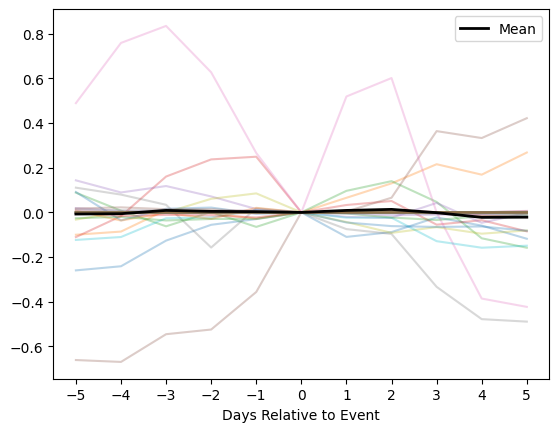

[ 0.         -0.00130112 -0.00096018]


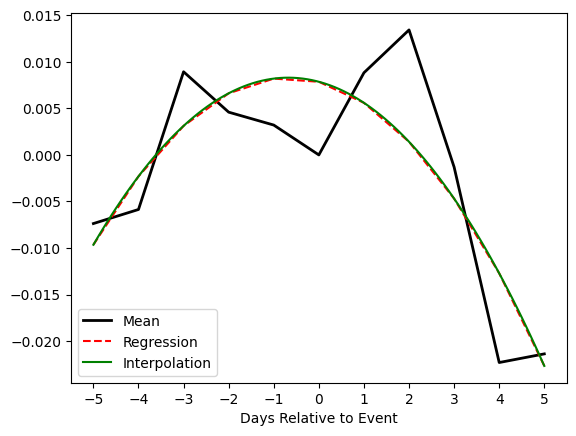

The Root Mean Squared Error is 0.006
The test score of the model is 0.570
The train score of the model is 0.602


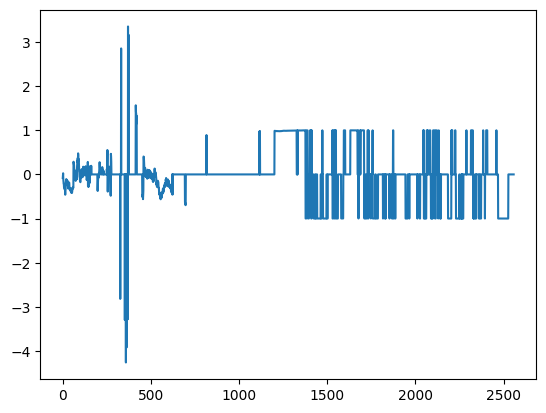

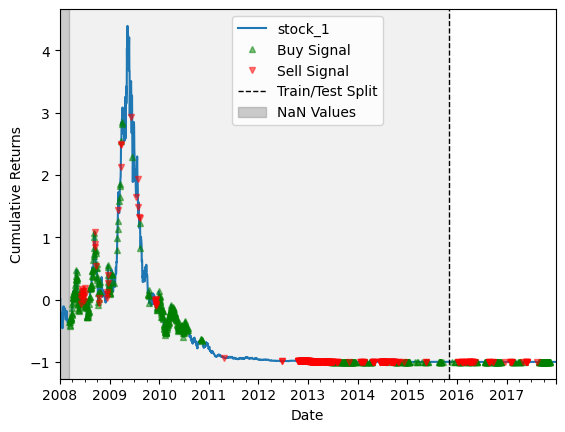

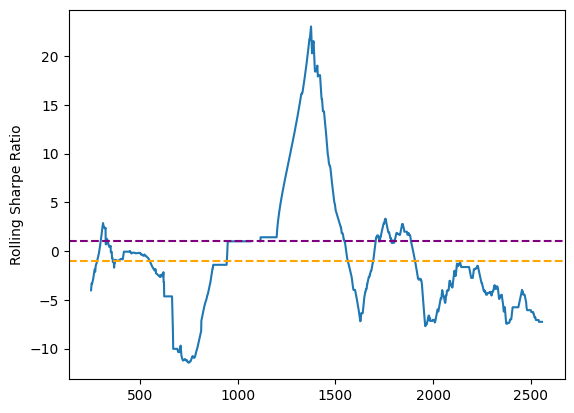

The Sharpe Ratio is -0.634


In [57]:
# Running the event driven trading strategy on stock_0 with a 5 day window
# First plot: The changes returns around the event dates
# Second plot: polynomial regression of the expected reaction to the event
# Third plot: ± daily returns from the buy and sell signals
# Fourth plot: Cumulative returns with the buy and sell signals overlaid. The test/train shown. NaN values shown on the left.
# Fifth plot: Rolling Sharpe Ratio of the strategy

EventsTradingStrategy_ML('stock_1', df_stock_returns, df_events, 5, rmse_threshold=0.01, plot = True).regression_test()

# Conclusion and Future Research Directions

In conclusion I attempted to implement two types of alpha generating strategies. One that trades the principle of mean reversion between spread of pairs, and one that trades off the expected moves from events. Although these models didn't necessarily produce the most optimal results due to their simplicity, it was still really cool to see that the ML back-tests on the whole 10 year dataset still produced some periods where the alpha was significant. 

### Future Directions If I Could Spend More Time

- Optimise the classifiers: More feature engineering, finding the best features for the training model. Consider PCA or correlated features reduction.
- Tune the hyperparamters for the random forest classifiers
- Try other ML implementations such as Gradient boosted trees (XGBoost), SVMs etc. to see if they provide more consistent results
- Try to implement time series forecasting methods as a possible feature (ARIMA)
- Stress testing of the model (high vol, seaonalitity)
- Compare the risk adjusted return to benchmark indices
